In [24]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.stommel import Stommel

{}


## CCModel

### Construction and `param_values`

Model parameters are stored in `param_values` — a dict mapping names to constants,
callables, or `Forcing` objects. Every subclass populates it at `__init__`.

In [25]:
# Construct with keyword arguments
model = Stommel(E=0.3, T_star=1.0, S_star=0.0)

print("param_values:", model.param_values)

param_values: {'alpha': 1.0, 'beta': 1.0, 'k': 1.0, 'E': 0.3, 'lambda_T': 1.0, 'lambda_S': 1.0, 'T_star': 1.0, 'S_star': 0.0}
{}


### Exploring a model: `.list()` and `.doc()`

`.list(target)` returns the names of a category; `.doc(target)` pretty-prints
descriptions parsed from the class docstring, alongside current values.

Valid targets: `"parameters"`, `"state_variables"`, `"diagnostic_variables"`.

In [26]:
# What parameters does this model have?
print("parameters:          ", model.list("parameters"))
print("state_variables:     ", model.list("state_variables"))
print("diagnostic_variables:", model.list("diagnostic_variables"))

parameters:           ['alpha', 'beta', 'k', 'E', 'lambda_T', 'lambda_S', 'T_star', 'S_star']
state_variables:      ['T', 'S']
diagnostic_variables: ['q']
{}


In [27]:
# Full descriptions + current values for parameters
model.doc("parameters")


Parameters — Stommel
═════════════════════════════════════════════════════════════════════════════
Name      Current value  Description
─────────────────────────────────────────────────────────────────────────────
alpha     1              Thermal expansion coefficient.  Default 1.0.
beta      1              Haline contraction coefficient.  Default 1.0.
k         1              Hydraulic constant controlling overturning
                         sensitivity.  Default 1.0.
E         0.3            Net evaporation-minus-precipitation freshwater flux.
                         Default 0.0.
lambda_T  1              Thermal restoring rate.  Default 1.0.
lambda_S  1              Saline restoring rate.  Default 1.0.
T_star    1              Equilibrium temperature contrast.  Default 1.0.
S_star    0              Equilibrium salinity contrast.  Default 0.0.
═════════════════════════════════════════════════════════════════════════════

{}


In [28]:
# State variable descriptions
model.doc("state_variables")


State variables — Stommel
══════════════════════════════════════════════════════════════════════
Name  Kind        Description
──────────────────────────────────────────────────────────────────────
T     integrated  
S     integrated  
══════════════════════════════════════════════════════════════════════

{}


### Updating parameters

Two equivalent ways to change a parameter after construction:

In [29]:
# Option 1: direct attribute assignment — syncs param_values automatically
model.E = 0.5
print("E after direct assignment:", model.param_values["E"])

# Option 2: set_param_value — also adds keys not present at init
model.set_param_value("E", 0.3)   # reset
print("E after reset:            ", model.param_values["E"])

E after direct assignment: 0.5
E after reset:             0.3
{}


### Callable parameters

Any `param_values` entry can be a callable instead of a scalar. The dispatcher
inspects the signature and accepts `(t)`, `(t, state)`, or `(t, state, model)`.
The first argument must be named `t` or `time`.

In [30]:
# E as a callable — gradual freshwater increase
def E_ramp(t):
    return np.clip(0.012 * t, 0.0, 0.6)

model_callable = Stommel(E=E_ramp, T_star=1.0, S_star=0.0)
out_callable = model_callable.integrate(t_span=(0, 50), y0=[1.0, 0.0], method="RK45")

{}


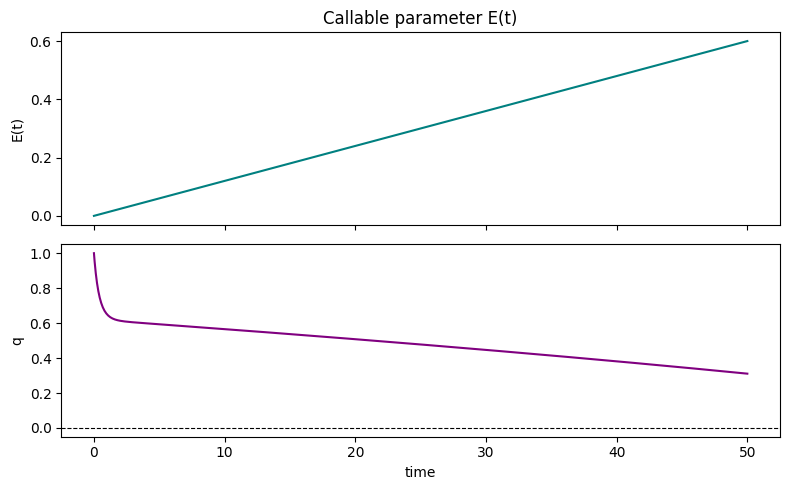

{}


In [31]:
t_plot = np.linspace(0, 50, 300)
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(t_plot, [E_ramp(t) for t in t_plot], color="teal")
axes[0].set_ylabel("E(t)"); axes[0].set_title("Callable parameter E(t)")
axes[1].plot(out_callable.time, out_callable.diagnostic_variables["q"], color="purple")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_ylabel("q"); axes[1].set_xlabel("time")
plt.tight_layout(); plt.show()

### `register_forcing`

Attaches a `Forcing` object to a named parameter or state variable after construction.
Wraps `dydt` transparently — no changes to the model subclass required.

See the [Forcing notebook](forcing.ipynb) for all construction patterns and the
full `register_forcing` contract (attachment styles, timing, noise).

In [32]:
# Freshwater pulse forcing
fw = cc.Forcing.from_sequence([
    cc.forcing.Hold(duration=10, value=0.0),
    cc.forcing.Ramp(duration=5,  y0=0.0, yf=0.5),
    cc.forcing.Hold(duration=15, value=0.5),
    cc.forcing.Ramp(duration=5,  y0=0.5, yf=0.0),
    cc.forcing.Hold(duration=15, value=0.0),
])

# Attach to E parameter (replacement — overrides E=0 set at construction)
model_forced = Stommel(E=0.0, T_star=1.0, S_star=0.0)
model_forced.register_forcing("E", fw)
out_forced = model_forced.integrate(t_span=(0, 50), y0=[1.0, 0.0], method="RK45")

{}


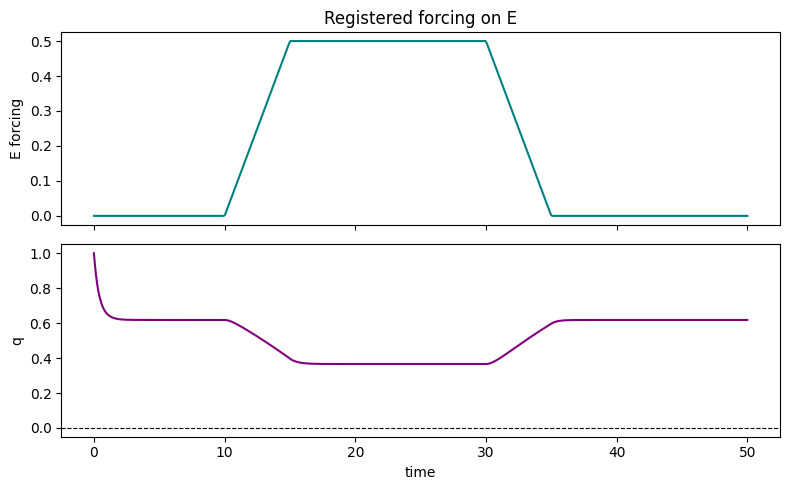

{}


In [33]:
t_plot = np.linspace(0, 50, 500)
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(t_plot, [fw.get_forcing(t) for t in t_plot], color="teal")
axes[0].set_ylabel("E forcing"); axes[0].set_title("Registered forcing on E")
axes[1].plot(out_forced.time, out_forced.diagnostic_variables["q"], color="purple")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_ylabel("q"); axes[1].set_xlabel("time")
plt.tight_layout(); plt.show()

### Copying a model

`copy.copy(model)` creates a shallow copy with reset diagnostic accumulators —
useful for running ensembles from the same parameter set without interference.

In [34]:
import copy

base = Stommel(E=0.3, T_star=1.0, S_star=0.0)
runs = []
for T0 in [0.5, 1.0, 1.5, 2.0]:
    m = copy.copy(base)   # fresh accumulators, same parameters
    out = m.integrate(t_span=(0, 50), y0=[T0, 0.0], method="RK45")
    runs.append((T0, out))

{}


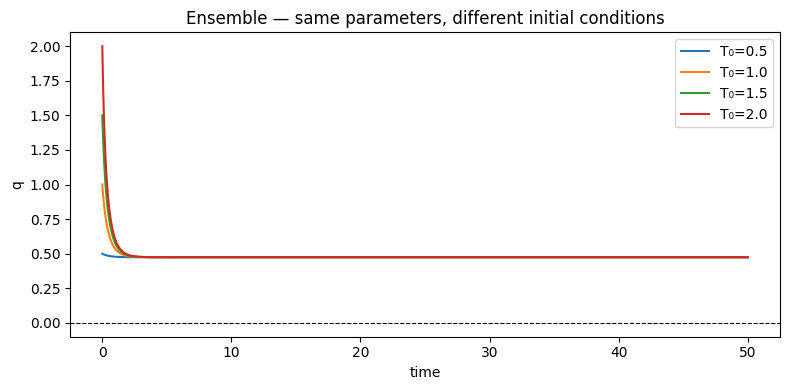

{}


In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
for T0, out in runs:
    ax.plot(out.time, out.diagnostic_variables["q"], label=f"T₀={T0}")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("time"); ax.set_ylabel("q")
ax.set_title("Ensemble — same parameters, different initial conditions")
ax.legend(); plt.tight_layout(); plt.show()

## CCOutput

`CCModel.integrate()` returns a `CCOutput` — a container for one run's results.
It is never constructed directly; you always get one from `integrate()`.

Separating output from model configuration means a single model instance can
produce multiple independent outputs without them overwriting each other.

In [36]:
# A basic run to work with throughout this section
model = Stommel(E=0.3, T_star=1.0, S_star=0.0)
output = model.integrate(t_span=(0, 50), y0=[1.0, 0.0], method="RK45")

print(f"run_name:              {output.run_name}")
print(f"time axis length:      {len(output.time)}")
print(f"state_variable_names:  {output.state_variable_names}")
print(f"diagnostic keys:       {list(output.diagnostic_variables.keys())}")

run_name:              RK45, dt=variable
time axis length:      84
state_variable_names:  ['T', 'S']
diagnostic keys:       ['q']
{}


### Accessing state variables and diagnostics

State variables are stored in a **structured numpy array**, indexed by name.
Diagnostics are in a plain **dict of arrays**. Both are aligned to `output.time`.

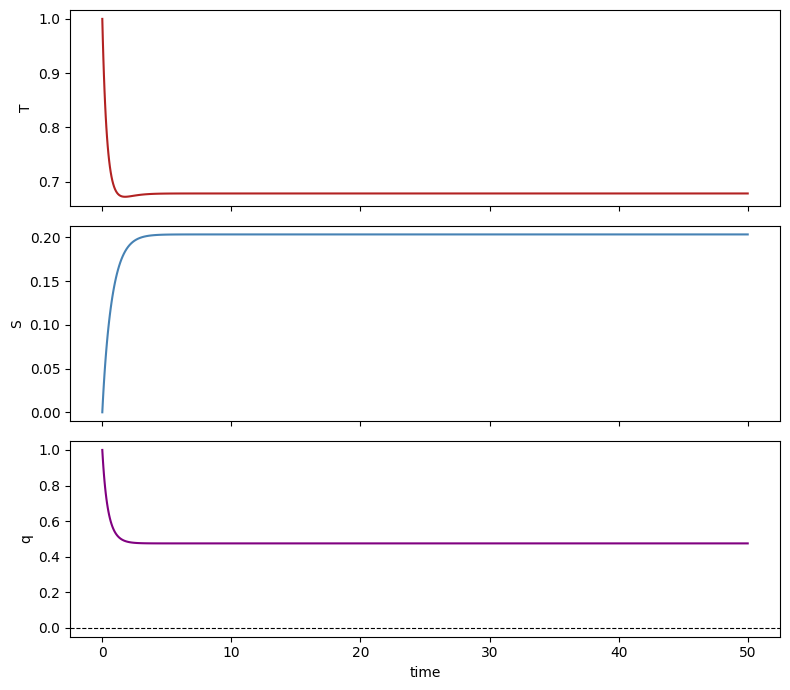

{}


In [37]:
# State variables — structured array, index by name
T = output.state_variables["T"]
S = output.state_variables["S"]

# Diagnostics — dict of arrays
q = output.diagnostic_variables["q"]

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
axes[0].plot(output.time, T, color="firebrick"); axes[0].set_ylabel("T")
axes[1].plot(output.time, S, color="steelblue"); axes[1].set_ylabel("S")
axes[2].plot(output.time, q, color="purple")
axes[2].axhline(0, color="k", lw=0.8, ls="--")
axes[2].set_ylabel("q"); axes[2].set_xlabel("time")
plt.tight_layout(); plt.show()

### `to_pyleo` — exporting to pyleoclim

`output.to_pyleo(var_names)` returns a `pyleoclim.Series` (single variable) or
`pyleoclim.MultipleSeries` (list of variables). Works for both state variables
and diagnostics.

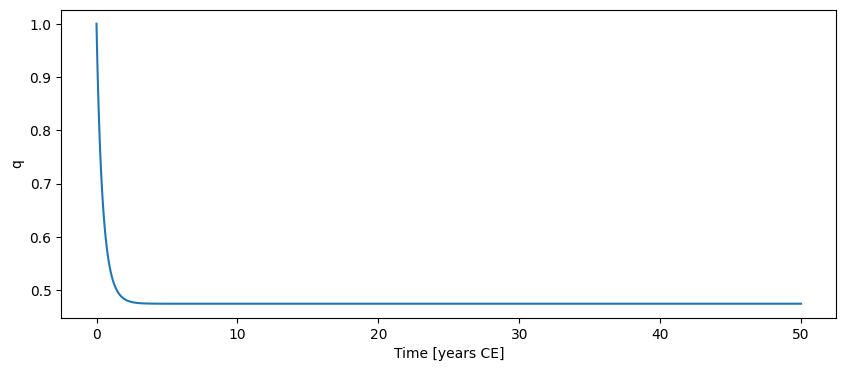

{}


In [38]:
# Single variable → pyleoclim.Series
ts_q = output.to_pyleo(var_names=["q"])
ts_q.plot(); plt.show()

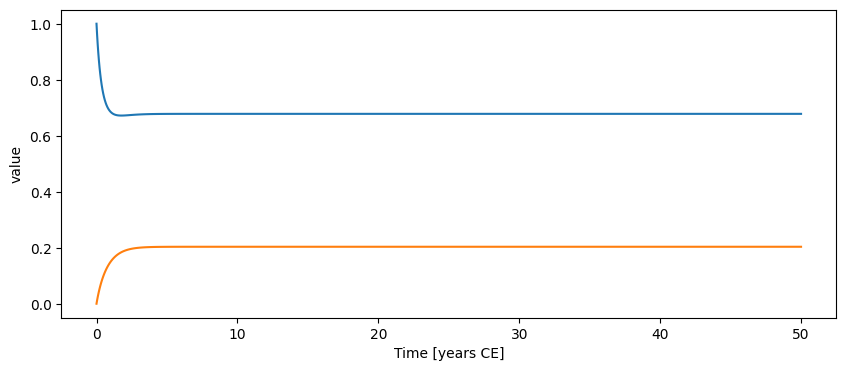

{}


In [39]:
# Multiple variables → pyleoclim.MultipleSeries
ms = output.to_pyleo(var_names=["T", "S"])
ms.plot(); plt.show()

### `reframe_time_axis` — resampling onto a new grid

Resamples state variables onto a requested time axis using the solver's dense output
(polynomial interpolation for RK45; linear fallback for fixed-step solvers).
`output.model_time` always retains the solver's original grid; `output.time` and
`output.state_variables` are replaced.

In [40]:
import copy

# Work on a copy so the original output is unchanged
out_reframed = copy.copy(output)
out_reframed.reframe_time_axis(np.linspace(0, 50, 200))   # uniform 200-point grid

print(f"original grid:  {len(output.time)} points")
print(f"reframed grid:  {len(out_reframed.time)} points")

original grid:  84 points
reframed grid:  200 points
{}


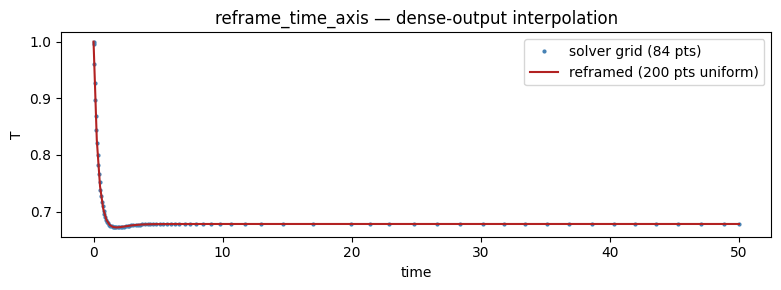

{}


In [41]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(output.time,        output.state_variables["T"],
        "o", ms=2, color="steelblue", label=f"solver grid ({len(output.time)} pts)")
ax.plot(out_reframed.time,  out_reframed.state_variables["T"],
        color="firebrick", lw=1.5, label="reframed (200 pts uniform)")
ax.set_xlabel("time"); ax.set_ylabel("T")
ax.set_title("reframe_time_axis — dense-output interpolation")
ax.legend(); plt.tight_layout(); plt.show()

### `add_noise` / `remove_noise` — post-hoc noise

Adds externally supplied noise to any state or diagnostic variable after integration.
The original clean values are saved on the first call so `remove_noise` can restore them.
Useful for simulating observation uncertainty without re-running the model.

In [42]:
import copy

out_noisy = copy.copy(output)   # work on a copy

# Generate white noise scaled to ~2% of the q range
rng   = np.random.default_rng(42)
noise = rng.normal(0, 0.02, size=len(out_noisy.diagnostic_variables["q"]))

out_noisy.add_noise("q", noise)
print("noisy  q range:", out_noisy.diagnostic_variables["q"].min().round(3),
      "–", out_noisy.diagnostic_variables["q"].max().round(3))

noisy  q range: 0.441 – 1.006
{}


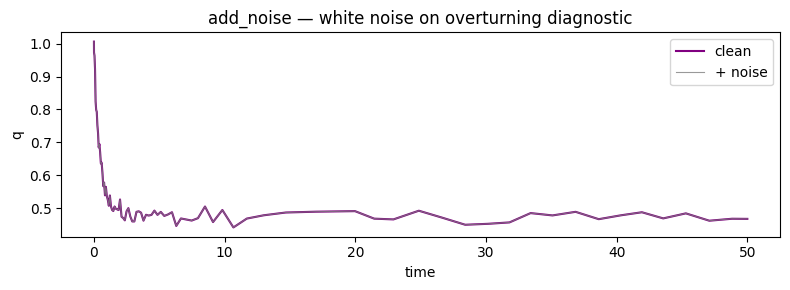

{}


In [43]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(output.time,      output.diagnostic_variables["q"],
        color="purple", lw=1.5, label="clean")
ax.plot(out_noisy.time,   out_noisy.diagnostic_variables["q"],
        color="gray", lw=0.8, alpha=0.8, label="+ noise")
ax.set_xlabel("time"); ax.set_ylabel("q")
ax.set_title("add_noise — white noise on overturning diagnostic")
ax.legend(); plt.tight_layout(); plt.show()

In [44]:
# Restore the clean series
out_noisy.remove_noise("q")
print("after remove_noise, q matches original:",
      np.allclose(out_noisy.diagnostic_variables["q"],
                  output.diagnostic_variables["q"]))

after remove_noise, q matches original: True
{}


## Advanced

The features below are less commonly needed but can be useful for experiments
that would otherwise require writing a new subclass.

### `set_function` — swapping a calculation method

Replaces a model calculation method on a single instance without subclassing.
The replacement callable can be bound as an instance method (first arg named `self`
or `model`) or as a plain function (any other first arg name); `bind` is inferred
automatically or can be set explicitly.

In [45]:
# Replace the overturning formula on one instance only
def weaker_overturning(self, t, x):
    """Overturning with halved hydraulic constant k."""
    T, S = x[0], x[1]
    alpha = self.get_param_value("alpha", t, x)
    beta  = self.get_param_value("beta",  t, x)
    k     = self.get_param_value("k",     t, x)
    return (k / 2.0) * (alpha * T - beta * S)

model_alt = Stommel(E=0.3, T_star=1.0, S_star=0.0)
model_alt.set_function("overturning", weaker_overturning)
out_alt = model_alt.integrate(t_span=(0, 50), y0=[1.0, 0.0], method="RK45")

{}


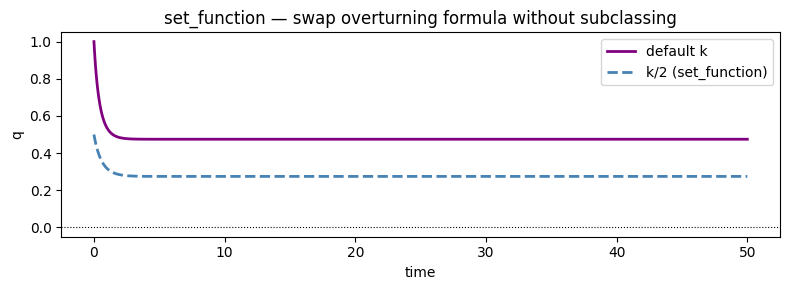

{}


In [46]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(output.time,   output.diagnostic_variables["q"],
        color="purple", lw=2, label="default k")
ax.plot(out_alt.time,  out_alt.diagnostic_variables["q"],
        color="steelblue", ls="--", lw=2, label="k/2 (set_function)")
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel("time"); ax.set_ylabel("q")
ax.set_title("set_function — swap overturning formula without subclassing")
ax.legend(); plt.tight_layout(); plt.show()